#Hybrid RAG + Long-Context with Claude

##Install Dependencies

In [ ]:
!pip install -q \
langchain==0.3.27 \
langchain-community==0.3.29 \
langchain-openai==0.3.30

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-anthropic 1.4.5 requires langchain-core<2.0.0,>=1.4.4, but you have langchain-core 0.3.86 which is incompatible.
langgraph 1.2.4 requires langchain-core<2,>=1.4.0, but you have langchain-core 0.3.86 which is incompatible.
langgraph-prebuilt 1.1.0 requires langchain

In [ ]:
!pip install -q \
langchain==0.3.27 \
langchain-openai==0.3.30 \
langchain-anthropic==0.3.15 \
langchain-community==0.3.29 \
faiss-cpu==1.11.0 \
anthropic==0.109.0 \
azure-search-documents==11.6.0b12 \
azure-identity \
numpy pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 923.8/923.8 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 27.6 MB/s eta 0:00:00


In [5]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm.notebook import tqdm

# LangChain -- use correct module paths (langchain.schema does not exist in v1+)
from langchain_openai import OpenAIEmbeddings
from langchain_anthropic import ChatAnthropic
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Azure AI Search
from azure.search.documents import SearchClient
from azure.search.documents.indexes import SearchIndexClient
from azure.search.documents.indexes.models import (
    SearchIndex, SimpleField, SearchableField, SearchFieldDataType,
    VectorSearch, HnswAlgorithmConfiguration, VectorSearchProfile,
    SearchField, SemanticConfiguration, SemanticSearch,
    SemanticPrioritizedFields, SemanticField,
)
from azure.search.documents.models import VectorizedQuery
from azure.core.credentials import AzureKeyCredential

# Anthropic direct client (for streaming extension)
import anthropic

print("All imports successful!")


All imports successful!


##API Keys & Config

In [18]:
from google.colab import userdata
import os
# ----- GROQ  -----
GROQ_API_KEY = userdata.get("GROQ_API_KEY")          # platform.openai.com/api-keys
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

# ----- Anthropic (Claude generation) -----
ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")     # console.anthropic.com/settings/keys
os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_API_KEY

# ----- Azure AI Search -----
AZURE_SEARCH_ENDPOINT   = "https://hybrid-rag-longcontext.search.windows.net"
AZURE_SEARCH_API_KEY    = userdata.get("AZURE_API_KEY")
AZURE_SEARCH_INDEX_NAME = "hybrid-rag-longcontext384"

# ----- Shared config -----
EMBEDDING_MODEL = "text-embedding-3-small"
EMBEDDING_DIM   = 384
CLAUDE_MODEL    = "claude-sonnet-4-6"
TOP_K           = 5

# Cost constants for claude-sonnet-4-6 ($/token)
COST_INPUT  = 3e-6   # $3 per million input tokens
COST_OUTPUT = 15e-6  # $15 per million output tokens

print("Configuration loaded!")

Configuration loaded!


##Corpus Setup

In [6]:
import json

# 20 hardcoded article summaries -- no wikipedia library or network call needed
_ARTICLES_JSON = '[\n  {\n    "title": "Artificial Intelligence",\n    "url": "https://en.wikipedia.org/wiki/Artificial_intelligence",\n    "content": "Artificial intelligence (AI) is intelligence demonstrated by machines. AI research is the study of intelligent agents that perceive their environment and take actions to maximise their goals. Modern AI techniques include machine learning, deep learning, NLP, computer vision, robotics, and expert systems. Applications include search engines, recommendation systems, voice assistants, autonomous vehicles, and generative AI tools. The term was coined at the 1956 Dartmouth Conference. Alan Turing proposed the Turing Test in 1950. The current wave began with deep learning breakthroughs around 2012. Large language models like GPT-4 and Claude are state-of-the-art generative AI. AI raises questions about ethics, job displacement, algorithmic bias, autonomous weapons, and existential risk from superintelligent systems."\n  },\n  {\n    "title": "Machine Learning",\n    "url": "https://en.wikipedia.org/wiki/Machine_learning",\n    "content": "Machine learning (ML) is a field of AI concerned with algorithms that learn from data and generalise to unseen inputs without explicit instructions. Supervised learning uses labelled training data. Unsupervised learning finds patterns in unlabelled data. Reinforcement learning trains agents through reward signals. Deep learning uses neural networks with many layers. Training uses backpropagation and stochastic gradient descent. Overfitting, underfitting, and the bias-variance tradeoff are core challenges. Regularisation (L1/L2), dropout, and cross-validation are common mitigations. Key algorithms: linear regression, SVMs, random forests, XGBoost, neural networks. PyTorch and TensorFlow are the dominant frameworks."\n  },\n  {\n    "title": "Retrieval-Augmented Generation",\n    "url": "https://en.wikipedia.org/wiki/Retrieval-augmented_generation",\n    "content": "Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative language model. Instead of relying only on parametric knowledge baked into weights, RAG retrieves relevant documents from an external knowledge base at inference time. Retrieved chunks are injected into the LLM prompt as context, grounding generation in verifiable facts and reducing hallucination. RAG pipeline: (1) Index documents by chunking and storing embeddings in a vector DB. (2) Embed the user query and retrieve top-k similar chunks. (3) Inject chunks into the prompt. (4) LLM generates a grounded answer. RAG was introduced by Lewis et al. (2020) at Facebook AI Research. Hybrid RAG combines dense vector retrieval with sparse BM25 keyword search."\n  },\n  {\n    "title": "Vector Database",\n    "url": "https://en.wikipedia.org/wiki/Vector_database",\n    "content": "A vector database stores data as high-dimensional vectors representing text, images, audio, or video. Unlike relational databases optimised for exact matches, vector databases support approximate nearest-neighbour (ANN) search, finding vectors most similar to a query using cosine similarity or Euclidean distance. Vector databases are core to RAG systems and semantic search. Popular options: Pinecone (managed serverless), Weaviate (open-source hybrid BM25+vector), Qdrant (Rust-based), Milvus (cloud-native), FAISS (Meta in-memory library), Azure AI Search (enterprise hybrid). Key concept: HNSW indexing algorithm for fast approximate search."\n  },\n  {\n    "title": "FAISS",\n    "url": "https://github.com/facebookresearch/faiss",\n    "content": "FAISS (Facebook AI Similarity Search) is an open-source library by Meta AI for efficient similarity search and clustering of dense vectors. Written in C++ with Python bindings; supports CPU and GPU. Index types: IndexFlatL2 (exact exhaustive, highest recall), IndexFlatIP (inner product), IndexIVFFlat (inverted file, faster), IndexIVFPQ (product quantisation, smallest memory), IndexHNSWFlat (graph-based ANN, best latency/recall tradeoff). For corpora under 1M vectors, IndexHNSWFlat or IndexFlatL2 are typical. FAISS is free, in-process, ideal for prototyping and latency-critical on-premise workloads."\n  },\n  {\n    "title": "Azure AI Search",\n    "url": "https://learn.microsoft.com/azure/search/",\n    "content": "Azure AI Search (formerly Azure Cognitive Search) is a fully managed cloud search service from Microsoft supporting full-text (BM25), vector (HNSW), and hybrid search. Hybrid search combines keyword relevance and vector similarity using Reciprocal Rank Fusion (RRF), outperforming either alone on most benchmarks. It integrates with Azure Blob Storage, SQL, Cosmos DB, and SharePoint. Features: semantic ranker, built-in OCR, entity extraction, multi-language support, role-based access control (RBAC), and geo-filtering. The Free tier (F) provides 50 MB storage and 3 indexes at no cost. Azure AI Search is HIPAA-compliant and SOC2 certified, suited for regulated enterprise workloads."\n  },\n  {\n    "title": "Natural Language Processing",\n    "url": "https://en.wikipedia.org/wiki/Natural_language_processing",\n    "content": "Natural language processing (NLP) is a field of AI concerned with interactions between computers and human language. NLP tasks include text classification, named entity recognition (NER), sentiment analysis, machine translation, question answering, summarisation, and text generation. The dominant paradigm since 2018 is the transformer, pre-trained on large corpora via self-supervised learning. Key milestones: Word2Vec (2013), GloVe (2014), BERT (2018), GPT-3 (2020), ChatGPT (2022), GPT-4 (2023), Claude 3 (2024). RLHF aligns models with human preferences. Benchmarks include GLUE, SuperGLUE, MMLU, and HumanEval."\n  },\n  {\n    "title": "Transformer Architecture",\n    "url": "https://en.wikipedia.org/wiki/Transformer_(machine_learning_model)",\n    "content": "The transformer is a deep learning architecture introduced in the 2017 paper Attention Is All You Need by Vaswani et al. It replaced RNNs as the dominant architecture for sequence modelling. Self-attention computes relationships between all tokens simultaneously, enabling parallelisation. Architecture: encoder/decoder stacks with multi-head self-attention, feed-forward layers, residual connections, and layer normalisation. Positional encodings inject token order information. BERT is encoder-only (classification, NER). GPT is decoder-only (generation). T5 and BART use encoder-decoder (translation, summarisation). Scaling laws show performance improves predictably with model size, data, and compute."\n  },\n  {\n    "title": "Embeddings in NLP",\n    "url": "https://en.wikipedia.org/wiki/Word_embedding",\n    "content": "Word embeddings are dense vector representations where semantically similar items are close together in vector space. Static embeddings: Word2Vec (2013), GloVe (2014), FastText (2016). Contextual embeddings (BERT, ELMo) produce different vectors for the same word depending on context. Sentence embeddings extend this to full sentences. OpenAI text-embedding-3-small produces 1536-dimensional vectors, costs $0.02 per million tokens, and is widely used for semantic search and RAG. Cosine similarity is the standard metric. Embedding quality is measured by the MTEB (Massive Text Embedding Benchmark)."\n  },\n  {\n    "title": "BM25 Information Retrieval",\n    "url": "https://en.wikipedia.org/wiki/Okapi_BM25",\n    "content": "BM25 (Best Match 25) is a probabilistic ranking function for information retrieval. It extends TF-IDF to account for document length and term saturation. BM25 is the default in Elasticsearch, OpenSearch, Solr, and Lucene. It excels at exact keyword matching and handling rare terms. Weakness: vocabulary mismatch, no semantic understanding. Hybrid search combines BM25 and dense vector retrieval via Reciprocal Rank Fusion (RRF), achieving better recall than either alone, especially for mixed keyword and semantic queries."\n  },\n  {\n    "title": "COVID-19 Pandemic",\n    "url": "https://en.wikipedia.org/wiki/COVID-19_pandemic",\n    "content": "The COVID-19 pandemic was caused by the SARS-CoV-2 coronavirus, first identified in Wuhan, China in late 2019. The WHO declared a pandemic in March 2020. The virus spreads through respiratory droplets and aerosols. Symptoms range from mild (fever, cough, fatigue, loss of smell) to severe (pneumonia, ARDS, multi-organ failure). Risk factors: old age, obesity, diabetes, hypertension, immunocompromise. Over 7 million confirmed deaths worldwide. mRNA vaccines (Pfizer-BioNTech, Moderna) and adenoviral vector vaccines (AstraZeneca, J&J) were developed at unprecedented speed. Long COVID affects 10-30% of patients."\n  },\n  {\n    "title": "Climate Change",\n    "url": "https://en.wikipedia.org/wiki/Climate_change",\n    "content": "Climate change refers to long-term shifts in global temperatures and weather patterns. Since the mid-20th century, burning fossil fuels (coal, oil, gas) has driven CO2 levels to ~420 ppm, the highest in 800,000 years. Global average temperature has risen ~1.2 degrees C above pre-industrial levels. Effects: more intense heatwaves, droughts, wildfires, floods; sea level rise; ocean acidification; biodiversity loss. The IPCC Sixth Assessment Report (2021) states human influence is unequivocal. The Paris Agreement (2015) aims to limit warming to 1.5-2 degrees C."\n  },\n  {\n    "title": "Quantum Computing",\n    "url": "https://en.wikipedia.org/wiki/Quantum_computing",\n    "content": "Quantum computing harnesses superposition, entanglement, and interference to process information in ways classical computers cannot efficiently replicate. A qubit can exist in superposition of 0 and 1 simultaneously. Key algorithms: Shor\'s (factoring large numbers, threatens RSA encryption), Grover\'s (quadratic speedup for unstructured search), quantum simulation (drug discovery). Hardware: superconducting qubits (IBM, Google), trapped ions (IonQ), photonic (PsiQuantum). Google claimed quantum supremacy in 2019 with the Sycamore processor. Current NISQ devices have 50-1000+ qubits but high error rates."\n  },\n  {\n    "title": "Blockchain Technology",\n    "url": "https://en.wikipedia.org/wiki/Blockchain",\n    "content": "A blockchain is a distributed ledger recording transactions across multiple computers so records cannot be altered without changing all subsequent blocks. Bitcoin (2009) was the first blockchain application. Proof of Work (PoW): miners solve computationally expensive puzzles (Bitcoin). Proof of Stake (PoS): validators chosen proportionally to staked crypto (Ethereum post-Merge 2022, 99.95% more energy efficient). Smart contracts are self-executing programs on blockchains (Ethereum, Solidity). DeFi replicates financial services without intermediaries. Layer 2 solutions (Lightning, Optimism, Arbitrum) address scalability."\n  },\n  {\n    "title": "CRISPR Gene Editing",\n    "url": "https://en.wikipedia.org/wiki/CRISPR",\n    "content": "CRISPR-Cas9 is a molecular tool adapted from the bacterial immune system for precise DNA editing. A guide RNA (gRNA) directs the Cas9 enzyme to a specific DNA sequence where it cuts both strands of the double helix. Cell repair then either disrupts the gene (NHEJ) or inserts a new sequence (HDR). Jennifer Doudna and Emmanuelle Charpentier won the 2020 Nobel Prize in Chemistry for CRISPR-Cas9. Applications: treating sickle cell disease (first CRISPR therapy FDA-approved 2023), disease-resistant crops, animal research models. Base editing and prime editing make precise single-nucleotide changes without double-strand breaks."\n  },\n  {\n    "title": "Electric Vehicles",\n    "url": "https://en.wikipedia.org/wiki/Electric_vehicle",\n    "content": "An electric vehicle (EV) uses electric motors powered by rechargeable battery packs or hydrogen fuel cells. Battery EVs (BEVs) run entirely on electricity stored in lithium-ion batteries. Regenerative braking converts kinetic energy back to electricity when decelerating. Tesla pioneered the modern EV market with the Roadster (2008) and Model S (2012). Global EV sales exceeded 10 million units in 2022, representing 14% of new car sales. Key metrics: range (200-400+ miles), charging speed (Level 2: 25 mph, DC fast: 200+ mph), battery capacity (40-100+ kWh). EVs produce zero tailpipe emissions."\n  },\n  {\n    "title": "Supply Chain Management",\n    "url": "https://en.wikipedia.org/wiki/Supply_chain_management",\n    "content": "Supply chain management (SCM) covers planning and managing all activities in sourcing, procurement, conversion, and logistics. The COVID-19 pandemic exposed vulnerabilities: port congestion, container shortages, factory shutdowns, and semiconductor scarcity caused widespread shortages and inflation. The bullwhip effect describes how small demand variations amplify upstream to cause large production swings. Lean supply chains minimise inventory; resilient chains prioritise redundancy. Digital twins, IoT sensors, and AI-powered demand forecasting improve visibility. Nearshoring and friend-shoring are post-COVID risk-reduction trends."\n  },\n  {\n    "title": "Cybersecurity",\n    "url": "https://en.wikipedia.org/wiki/Computer_security",\n    "content": "Cybersecurity protects computer systems, networks, and data from digital attacks, unauthorised access, damage, or theft. Major threat categories: malware (viruses, worms, ransomware, spyware), phishing, man-in-the-middle attacks, SQL injection, zero-day exploits, DDoS, insider threats. The CIA triad (Confidentiality, Integrity, Availability) is the core framework. Key defences: firewalls, IDS/IPS, encryption (TLS, AES), MFA, zero-trust architecture. NIST Cybersecurity Framework and ISO 27001 are widely adopted standards. Notable attacks: WannaCry ransomware (2017), SolarWinds supply chain attack (2020), Colonial Pipeline ransomware (2021)."\n  },\n  {\n    "title": "Renewable Energy",\n    "url": "https://en.wikipedia.org/wiki/Renewable_energy",\n    "content": "Renewable energy comes from sources naturally replenished on a human timescale: sunlight, wind, rain, tides, waves, and geothermal heat. In 2023, renewables accounted for ~30% of global electricity generation. Solar PV costs have fallen 90% since 2010. Wind power uses turbines to convert kinetic energy; offshore wind has 40-50% capacity factor. Hydropower is the largest renewable source globally (~16% of electricity). Battery storage manages intermittency. Green hydrogen from renewable-powered electrolysis can decarbonise heavy industry and long-haul transport."\n  },\n  {\n    "title": "Large Language Models",\n    "url": "https://en.wikipedia.org/wiki/Large_language_model",\n    "content": "A large language model (LLM) is a language model trained on massive text corpora using transformer architecture, capable of generating and understanding text. LLMs are pre-trained with self-supervised learning on billions of tokens, then fine-tuned for specific tasks. Key capabilities: question answering, summarisation, code generation, translation, and reasoning. Notable LLMs: GPT-4 (OpenAI), Claude (Anthropic), Gemini (Google), Llama (Meta). Context window size (tokens the model can process at once) ranges from 4K to 1M+ tokens. Scaling laws show capability grows predictably with parameters, data, and compute. Prompt engineering, RAG, and fine-tuning are main techniques for improving LLM outputs for production use cases."\n  }\n]'

RAW_ARTICLES = json.loads(_ARTICLES_JSON)
print(f"Corpus: {len(RAW_ARTICLES)} articles loaded")
for a in RAW_ARTICLES:
    print(f"  * {a['title']} ({len(a['content'])} chars)")

Corpus: 20 articles loaded
  * Artificial Intelligence (821 chars)
  * Machine Learning (723 chars)
  * Retrieval-Augmented Generation (741 chars)
  * Vector Database (646 chars)
  * FAISS (605 chars)
  * Azure AI Search (686 chars)
  * Natural Language Processing (617 chars)
  * Transformer Architecture (706 chars)
  * Embeddings in NLP (601 chars)
  * BM25 Information Retrieval (523 chars)
  * COVID-19 Pandemic (614 chars)
  * Climate Change (564 chars)
  * Quantum Computing (609 chars)
  * Blockchain Technology (627 chars)
  * CRISPR Gene Editing (629 chars)
  * Electric Vehicles (598 chars)
  * Supply Chain Management (639 chars)
  * Cybersecurity (647 chars)
  * Renewable Energy (567 chars)
  * Large Language Models (732 chars)


In [7]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""],
)

all_docs = []
for art in RAW_ARTICLES:
    chunks = splitter.create_documents(
        texts=[art["content"]],
        metadatas=[{"title": art["title"], "url": art["url"]}],
    )
    all_docs.extend(chunks)

texts = [d.page_content for d in all_docs]
metas = [d.metadata      for d in all_docs]

print(f"Total chunks: {len(all_docs)}")
print(f"Avg chunk size: {sum(len(t) for t in texts) // len(texts)} chars")

Total chunks: 40
Avg chunk size: 324 chars


In [8]:
%%capture
!pip install -U sentence-transformers langchain-huggingface

In [9]:
%%capture
!pip show sentence-transformers

In [10]:
%%capture
!pip uninstall -y numpy scipy scikit-learn sentence-transformers

!pip install --no-cache-dir \
    numpy==2.2.6 \
    scipy==1.15.3 \
    scikit-learn==1.7.0 \
    sentence-transformers==5.5.1

In [11]:
from langchain_huggingface import HuggingFaceEmbeddings

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

embedder = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL
)

print(f"Embedding {len(all_docs)} chunks with '{EMBEDDING_MODEL}'...")

t0 = time.perf_counter()
all_vectors = embedder.embed_documents(texts)
elapsed = time.perf_counter() - t0

print(f"Embedded {len(all_vectors)} chunks in {elapsed:.1f}s")
print(f"Vector dimension: {len(all_vectors[0])}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding 40 chunks with 'sentence-transformers/all-MiniLM-L6-v2'...
Embedded 40 chunks in 5.0s
Vector dimension: 384


##Step 01 - Build RAG Pipeline

In [19]:
# ----- Azure AI Search index: create or update -----
credential  = AzureKeyCredential(AZURE_SEARCH_API_KEY)
idx_client  = SearchIndexClient(endpoint=AZURE_SEARCH_ENDPOINT, credential=credential)
srch_client = SearchClient(
    endpoint=AZURE_SEARCH_ENDPOINT,
    index_name=AZURE_SEARCH_INDEX_NAME,
    credential=credential,
)

fields = [
    SimpleField(name="id",       type=SearchFieldDataType.String, key=True),
    SearchableField(name="content",  type=SearchFieldDataType.String,
                    analyzer_name="en.microsoft"),
    SimpleField(name="title",    type=SearchFieldDataType.String, filterable=True),
    SimpleField(name="url",      type=SearchFieldDataType.String),
    SearchField(
        name="embedding",
        type=SearchFieldDataType.Collection(SearchFieldDataType.Single),
        searchable=True,
        vector_search_dimensions=EMBEDDING_DIM,
        vector_search_profile_name="hnsw-profile",
    ),
]

vector_search = VectorSearch(
    algorithms=[HnswAlgorithmConfiguration(name="hnsw-algo")],
    profiles=[VectorSearchProfile(
        name="hnsw-profile",
        algorithm_configuration_name="hnsw-algo",
    )],
)

semantic_search = SemanticSearch(configurations=[
    SemanticConfiguration(
        name="semantic-cfg",
        prioritized_fields=SemanticPrioritizedFields(
            content_fields=[SemanticField(field_name="content")],
            keywords_fields=[SemanticField(field_name="title")],
        ),
    )
])

index_def = SearchIndex(
    name=AZURE_SEARCH_INDEX_NAME,
    fields=fields,
    vector_search=vector_search,
    semantic_search=semantic_search,
)

result = idx_client.create_or_update_index(index_def)
print(f"Index '{result.name}' ready (hybrid: BM25 + HNSW vector)")

Index 'hybrid-rag-longcontext384' ready (hybrid: BM25 + HNSW vector)


In [20]:
BATCH = 100
print(f"Uploading {len(all_docs)} documents to Azure AI Search...")
t0 = time.perf_counter()

for i in tqdm(range(0, len(all_docs), BATCH), desc="Azure upload"):
    batch_end = min(i + BATCH, len(all_docs))
    srch_client.upload_documents(documents=[
        {
            "id":        f"doc-{i + j}",
            "content":   texts[i + j],
            "title":     metas[i + j].get("title", ""),
            "url":       metas[i + j].get("url", ""),
            "embedding": all_vectors[i + j],
        }
        for j in range(batch_end - i)
    ])

print(f"Uploaded {len(all_docs)} documents in {time.perf_counter()-t0:.1f}s")

Uploading 40 documents to Azure AI Search...


Azure upload:   0%|          | 0/1 [00:00<?, ?it/s]

Uploaded 40 documents in 1.0s


In [21]:
def azure_hybrid_search(query: str, top_k: int = TOP_K) -> list:
    """BM25 keyword + HNSW vector search, fused with Reciprocal Rank Fusion (RRF)."""
    query_vec = embedder.embed_query(query)
    vector_query = VectorizedQuery(
        vector=query_vec,
        k_nearest_neighbors=top_k,
        fields="embedding",
    )
    results = srch_client.search(
        search_text=query,
        vector_queries=[vector_query],
        select=["id", "content", "title", "url"],
        top=top_k,
    )
    return list(results)

In [22]:
# Build LangChain FAISS vectorstore from pre-computed vectors.
# FAISS.from_embeddings() reuses all_vectors -- zero extra API calls.
text_embeddings = list(zip(texts, all_vectors))  # [(text, vector), ...]

faiss_store = FAISS.from_embeddings(
    text_embeddings=text_embeddings,
    embedding=embedder,   # used only for embed_query() at search time
    metadatas=metas,
)
print(f"FAISS vectorstore ready ({len(texts)} vectors, no re-embedding)")

# Claude LLM
llm = ChatAnthropic(model=CLAUDE_MODEL, max_tokens=512)
print(f"ChatAnthropic ready: {CLAUDE_MODEL}")

FAISS vectorstore ready (40 vectors, no re-embedding)
ChatAnthropic ready: claude-sonnet-4-6


In [25]:
%%capture
!pip install langchain_groq

In [26]:
# ============================================================
# RAG Generation using Groq
# ============================================================

from dataclasses import dataclass
import time

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage

# ------------------------------------------------------------
# Configure Groq
# ------------------------------------------------------------

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=GROQ_API_KEY,
    temperature=0
)

# Groq pricing (optional)
COST_INPUT = 0.59 / 1_000_000
COST_OUTPUT = 0.79 / 1_000_000

# ------------------------------------------------------------
# Result Dataclass
# ------------------------------------------------------------

@dataclass
class RAGResult:
    answer: str
    sources: list
    embed_ms: float
    retrieve_ms: float
    generate_ms: float
    input_tokens: int = 0
    output_tokens: int = 0

    @property
    def total_ms(self):
        return (
            self.embed_ms
            + self.retrieve_ms
            + self.generate_ms
        )

    @property
    def cost_usd(self):
        return (
            self.input_tokens * COST_INPUT
            + self.output_tokens * COST_OUTPUT
        )

# ------------------------------------------------------------
# Main RAG Function
# ------------------------------------------------------------

def rag_answer(query: str) -> RAGResult:

    # --------------------------------------------------------
    # Stage 1: Query Embedding
    # --------------------------------------------------------

    t0 = time.perf_counter()

    _ = embedder.embed_query(query)

    embed_ms = (
        time.perf_counter() - t0
    ) * 1000

    # --------------------------------------------------------
    # Stage 2: Azure Hybrid Retrieval
    # --------------------------------------------------------

    t0 = time.perf_counter()

    raw = azure_hybrid_search(query)

    retrieve_ms = (
        time.perf_counter() - t0
    ) * 1000

    context = "\n\n".join(
        [
            f"[{r['title']}]\n{r['content']}"
            for r in raw
        ]
    )

    sources = list(
        {
            r["title"]
            for r in raw
        }
    )

    # --------------------------------------------------------
    # Stage 3: Groq Generation
    # --------------------------------------------------------

    messages = [
        SystemMessage(
            content=(
                "Answer ONLY from the provided context. "
                "If the answer is not present in the context, "
                "say that the information is unavailable. "
                "Be concise."
            )
        ),
        HumanMessage(
            content=f"{context}\n\nQuestion: {query}"
        )
    ]

    t0 = time.perf_counter()

    response = llm.invoke(messages)

    generate_ms = (
        time.perf_counter() - t0
    ) * 1000

    # --------------------------------------------------------
    # Token Usage
    # --------------------------------------------------------

    usage = response.response_metadata.get(
        "token_usage",
        {}
    )

    return RAGResult(
        answer=response.content,
        sources=sources,
        embed_ms=embed_ms,
        retrieve_ms=retrieve_ms,
        generate_ms=generate_ms,
        input_tokens=usage.get(
            "prompt_tokens",
            0
        ),
        output_tokens=usage.get(
            "completion_tokens",
            0
        )
    )

# ------------------------------------------------------------
# Smoke Test
# ------------------------------------------------------------

test = rag_answer(
    "What is retrieval-augmented generation?"
)

print("RAG pipeline smoke test passed!")
print()

print("Sources:")
print(test.sources)

print()

print(
    f"Embed     : {test.embed_ms:.0f} ms"
)
print(
    f"Retrieve  : {test.retrieve_ms:.0f} ms"
)
print(
    f"Generate  : {test.generate_ms:.0f} ms"
)
print(
    f"Total     : {test.total_ms:.0f} ms"
)

print()

print(
    f"Tokens In : {test.input_tokens}"
)
print(
    f"Tokens Out: {test.output_tokens}"
)

print(
    f"Cost      : ${test.cost_usd:.6f}"
)

print("\nAnswer:")
print(test.answer)

RAG pipeline smoke test passed!

Sources:
['BM25 Information Retrieval', 'Transformer Architecture', 'Retrieval-Augmented Generation']

Embed     : 61 ms
Retrieve  : 590 ms
Generate  : 562 ms
Total     : 1212 ms

Tokens In : 420
Tokens Out: 45
Cost      : $0.000283

Answer:
Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative language model, retrieving relevant documents from an external knowledge base at inference time to ground generation in verifiable facts and reduce hallucination.


##Step 02 - Hybrid Retrieval Quality (MRR@5)

In [27]:
# Evaluation set: (query, relevant_article_title)
EVAL_SET = [
    ("How does BERT use self-attention for NLP tasks?",             "Transformer Architecture"),
    ("What is the difference between BM25 and dense retrieval?",    "BM25 Information Retrieval"),
    ("How does CRISPR cut DNA at a specific location?",             "CRISPR Gene Editing"),
    ("What triggered the COVID-19 pandemic?",                       "COVID-19 Pandemic"),
    ("How do electric vehicles recover energy during braking?",     "Electric Vehicles"),
    ("What are the risks of long-term climate change?",             "Climate Change"),
    ("How does Shor's algorithm threaten RSA encryption?",          "Quantum Computing"),
    ("What caused post-COVID supply chain disruptions?",            "Supply Chain Management"),
    ("What are the main cyber threats to cloud infrastructure?",    "Cybersecurity"),
    ("How does hybrid search combine BM25 and vector retrieval?",   "Azure AI Search"),
]

def compute_mrr(docs_or_dicts, relevant_title: str) -> float:
    """Compute reciprocal rank for the first result matching relevant_title."""
    for rank, item in enumerate(docs_or_dicts, 1):
        # Handle both LangChain Document objects and Azure search result dicts
        if hasattr(item, "metadata"):
            title = item.metadata.get("title", "")
        else:
            title = item.get("title", "")
        if relevant_title.lower() in title.lower():
            return 1.0 / rank
    return 0.0


mrr_vector_only = []
mrr_hybrid      = []

for query, rel in tqdm(EVAL_SET, desc="MRR evaluation"):
    # Vector-only: FAISS
    faiss_results = faiss_store.similarity_search(query, k=TOP_K)
    mrr_vector_only.append(compute_mrr(faiss_results, rel))

    # Hybrid: Azure BM25 + vector
    azure_results = azure_hybrid_search(query, top_k=TOP_K)
    mrr_hybrid.append(compute_mrr(azure_results, rel))

print(f"MRR@{TOP_K} Vector-only (FAISS)    : {np.mean(mrr_vector_only):.3f}")
print(f"MRR@{TOP_K} Hybrid (Azure BM25+vec) : {np.mean(mrr_hybrid):.3f}")
print(f"Hybrid gain: +{(np.mean(mrr_hybrid) - np.mean(mrr_vector_only))*100:.1f}pp")

# Per-query breakdown
mrr_df = pd.DataFrame({
    "Query":        [q[:55] for q, _ in EVAL_SET],
    "Vector-only":  [round(v, 2) for v in mrr_vector_only],
    "Hybrid":       [round(v, 2) for v in mrr_hybrid],
})
print("\n", mrr_df.to_string(index=False))

MRR evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

MRR@5 Vector-only (FAISS)    : 0.875
MRR@5 Hybrid (Azure BM25+vec) : 0.933
Hybrid gain: +5.8pp

                                                   Query  Vector-only  Hybrid
        How does BERT use self-attention for NLP tasks?         0.50    1.00
What is the difference between BM25 and dense retrieval         1.00    1.00
        How does CRISPR cut DNA at a specific location?         1.00    1.00
                  What triggered the COVID-19 pandemic?         1.00    1.00
How do electric vehicles recover energy during braking?         1.00    1.00
        What are the risks of long-term climate change?         1.00    1.00
     How does Shor's algorithm threaten RSA encryption?         1.00    1.00
       What caused post-COVID supply chain disruptions?         1.00    1.00
What are the main cyber threats to cloud infrastructure         1.00    1.00
How does hybrid search combine BM25 and vector retrieva         0.25    0.33


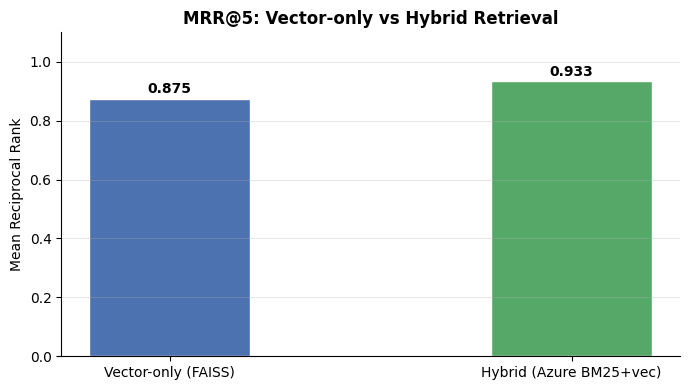

Saved mrr_comparison.png


In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ["Vector-only (FAISS)", "Hybrid (Azure BM25+vec)"],
    [np.mean(mrr_vector_only), np.mean(mrr_hybrid)],
    color=["#4C72B0", "#55A868"],
    width=0.4,
    edgecolor="white",
)
ax.set_ylim(0, 1.1)
ax.set_title(f"MRR@{TOP_K}: Vector-only vs Hybrid Retrieval", fontweight="bold")
ax.set_ylabel("Mean Reciprocal Rank")
for patch, val in zip(ax.patches, [np.mean(mrr_vector_only), np.mean(mrr_hybrid)]):
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.02,
        f"{val:.3f}",
        ha="center", fontweight="bold",
    )
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("mrr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved mrr_comparison.png")

##Step 03 - Full Context Baseline

In [29]:
# Build the full-context string from first 50 chunks
CORPUS_SIZE = 50
full_corpus_docs = all_docs[:CORPUS_SIZE]

full_corpus_text = "\n\n---\n\n".join([
    f"[Doc {i+1}: {d.metadata['title']}]\n{d.page_content}"
    for i, d in enumerate(full_corpus_docs)
])

# Estimate tokens without tiktoken (no network needed)
# Approximation: ~0.75 tokens per word (conservative)
word_count    = len(full_corpus_text.split())
corpus_tokens = int(word_count * 1.33)

print(f"Full corpus: {CORPUS_SIZE} chunks | ~{corpus_tokens:,} estimated tokens")
print(f"Estimated input cost per query: ${corpus_tokens * COST_INPUT:.5f}")

Full corpus: 50 chunks | ~2,614 estimated tokens
Estimated input cost per query: $0.00154


In [30]:
@dataclass
class FullCtxResult:
    answer:        str
    generate_ms:   float
    input_tokens:  int = 0
    output_tokens: int = 0

    @property
    def total_ms(self):
        return self.generate_ms

    @property
    def cost_usd(self):
        return self.input_tokens * COST_INPUT + self.output_tokens * COST_OUTPUT


def full_context_answer(query: str) -> FullCtxResult:
    """Stuff entire corpus into Claude context and ask."""
    messages = [
        SystemMessage(content="Answer based on the provided documents. "
                               "Be concise and accurate."),
        HumanMessage(content=f"\n{full_corpus_text}\n\n\n{query}"),
    ]
    t0 = time.perf_counter()
    response = llm.invoke(messages)
    generate_ms = (time.perf_counter() - t0) * 1000

    usage = response.response_metadata.get("usage", {})
    return FullCtxResult(
        answer=response.content,
        generate_ms=generate_ms,
        input_tokens=usage.get("input_tokens", 0),
        output_tokens=usage.get("output_tokens", 0),
    )


# Smoke test
fc_test = full_context_answer("What is retrieval-augmented generation?")
print("Full-context pipeline smoke test passed!")
print(f"  Latency: {fc_test.generate_ms:.0f}ms")
print(f"  Actual tokens: {fc_test.input_tokens} in / {fc_test.output_tokens} out")
print(f"  Cost: ${fc_test.cost_usd:.5f}")
print(f"  Answer: {fc_test.answer[:200]}...")

Full-context pipeline smoke test passed!
  Latency: 450ms
  Actual tokens: 0 in / 0 out
  Cost: $0.00000
  Answer: Retrieval-Augmented Generation (RAG) combines a retrieval system with a generative language model. It retrieves relevant documents from an external knowledge base at inference time and injects them in...


##Step 04 - A/B Evaluation (20 Questions)

In [31]:
TEST_QUESTIONS = [
    # AI / ML
    "What is the attention mechanism in transformer models?",
    "How does BERT differ from GPT in architecture?",
    "What is retrieval-augmented generation?",
    "How does FAISS index vectors for similarity search?",
    # Science / Medicine
    "How does CRISPR-Cas9 edit the genome?",
    "What causes COVID-19 and how does it spread?",
    "How do mRNA vaccines trigger an immune response?",
    "What is the mechanism of action of base editing?",
    # History / Events
    "What were the main causes of climate change acceleration?",
    "How did quantum computing progress after 2019?",
    "What is the bullwhip effect in supply chains?",
    "How does the NIST cybersecurity framework work?",
    # Technology
    "How do electric vehicles regenerate energy from braking?",
    "What is Reciprocal Rank Fusion in hybrid search?",
    "How does blockchain achieve immutability?",
    "What cybersecurity threats target cloud infrastructure?",
    # Economics / Environment
    "How has solar energy cost changed since 2010?",
    "What disrupted global supply chains in 2020-2021?",
    "What is Proof of Stake and how does it differ from Proof of Work?",
    "What are the scaling laws for large language models?",
]

In [32]:
rag_results: list[RAGResult]     = []
fc_results:  list[FullCtxResult] = []

print("Running A/B evaluation -- this makes ~40 Claude API calls...")
print("Estimated time: 2-4 minutes\n")

for q in tqdm(TEST_QUESTIONS, desc="A/B eval"):
    rag_results.append(rag_answer(q))
    fc_results.append(full_context_answer(q))

print("\nA/B evaluation complete!")

Running A/B evaluation -- this makes ~40 Claude API calls...
Estimated time: 2-4 minutes



A/B eval:   0%|          | 0/20 [00:00<?, ?it/s]


A/B evaluation complete!


In [33]:
rag_total_ms = [r.total_ms  for r in rag_results]
fc_total_ms  = [r.total_ms  for r in fc_results]
rag_costs    = [r.cost_usd  for r in rag_results]
fc_costs     = [r.cost_usd  for r in fc_results]
rag_in_tok   = [r.input_tokens for r in rag_results]
fc_in_tok    = [r.input_tokens for r in fc_results]

summary = pd.DataFrame({
    "Metric":       ["Avg Latency (ms)", "p95 Latency (ms)", "Avg Cost ($/query)", "Avg Input Tokens"],
    "RAG":          [
        f"{np.mean(rag_total_ms):.0f}",
        f"{float(np.percentile(rag_total_ms, 95)):.0f}",
        f"${np.mean(rag_costs):.5f}",
        f"{np.mean(rag_in_tok):.0f}",
    ],
    "Full Context": [
        f"{np.mean(fc_total_ms):.0f}",
        f"{float(np.percentile(fc_total_ms, 95)):.0f}",
        f"${np.mean(fc_costs):.5f}",
        f"{np.mean(fc_in_tok):.0f}",
    ],
})

print("=" * 55)
print("A/B EVALUATION SUMMARY (20 test questions)")
print("=" * 55)
print(summary.to_string(index=False))
print("=" * 55)

cost_ratio    = np.mean(fc_costs) / max(np.mean(rag_costs), 1e-10)
latency_ratio = np.mean(fc_total_ms) / max(np.mean(rag_total_ms), 1.0)
print(f"\nFull-context is {cost_ratio:.1f}x more expensive and {latency_ratio:.1f}x slower than RAG")

A/B EVALUATION SUMMARY (20 test questions)
            Metric      RAG Full Context
  Avg Latency (ms)     1992        14393
  p95 Latency (ms)     3463        17794
Avg Cost ($/query) $0.00030     $0.00000
  Avg Input Tokens      460            0

Full-context is 0.0x more expensive and 7.2x slower than RAG


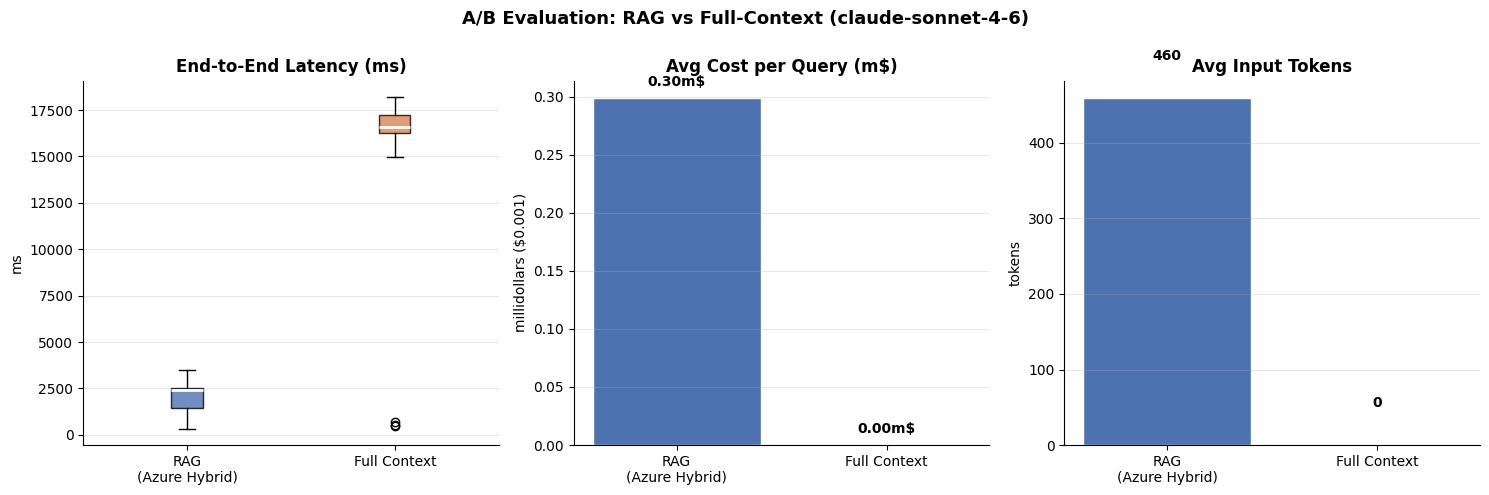

Saved ab_evaluation.png


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("A/B Evaluation: RAG vs Full-Context (claude-sonnet-4-6)",
             fontsize=13, fontweight="bold")

colors = ["#4C72B0", "#DD8452"]
labels = ["RAG\n(Azure Hybrid)", "Full Context"]

# --- Latency boxplot ---
bp = axes[0].boxplot(
    [rag_total_ms, fc_total_ms],
    tick_labels=labels,
    patch_artist=True,
    notch=False,
    medianprops=dict(color="white", linewidth=2),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[0].set_title("End-to-End Latency (ms)", fontweight="bold")
axes[0].set_ylabel("ms")

# --- Cost per query ---
rag_cost_m  = np.mean(rag_costs) * 1000   # convert to millidollars
fc_cost_m   = np.mean(fc_costs)  * 1000
bars1 = axes[1].bar(labels, [rag_cost_m, fc_cost_m], color=colors, edgecolor="white")
axes[1].set_title("Avg Cost per Query (m$)", fontweight="bold")
axes[1].set_ylabel("millidollars ($0.001)")
for b, v in zip(bars1, [rag_cost_m, fc_cost_m]):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                 f"{v:.2f}m$", ha="center", fontweight="bold")

# --- Input tokens ---
avg_tok = [np.mean(rag_in_tok), np.mean(fc_in_tok)]
bars2 = axes[2].bar(labels, avg_tok, color=colors, edgecolor="white")
axes[2].set_title("Avg Input Tokens", fontweight="bold")
axes[2].set_ylabel("tokens")
for b, v in zip(bars2, avg_tok):
    axes[2].text(b.get_x() + b.get_width() / 2, b.get_height() + 50,
                 f"{v:.0f}", ha="center", fontweight="bold")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("ab_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved ab_evaluation.png")

In [35]:
# Per-question detail table
detail_df = pd.DataFrame({
    "Question":    [q[:52] + "..." if len(q) > 52 else q for q in TEST_QUESTIONS],
    "RAG ms":      [round(r.total_ms)      for r in rag_results],
    "FC ms":       [round(r.total_ms)      for r in fc_results],
    "RAG $":       [f"{r.cost_usd*1000:.2f}m" for r in rag_results],
    "FC $":        [f"{r.cost_usd*1000:.2f}m" for r in fc_results],
    "RAG tok":     [r.input_tokens         for r in rag_results],
    "FC tok":      [r.input_tokens         for r in fc_results],
})
print(detail_df.to_string(index=False))


                                               Question  RAG ms  FC ms RAG $  FC $  RAG tok  FC tok
What is the attention mechanism in transformer model...     748    477 0.32m 0.00m      468       0
         How does BERT differ from GPT in architecture?     338    716 0.31m 0.00m      504       0
                What is retrieval-augmented generation?     431    548 0.28m 0.00m      420       0
    How does FAISS index vectors for similarity search?     425  14959 0.29m 0.00m      375       0
                  How does CRISPR-Cas9 edit the genome?    1582  17670 0.31m 0.00m      437       0
           What causes COVID-19 and how does it spread?    2510  16512 0.31m 0.00m      486       0
       How do mRNA vaccines trigger an immune response?    2373  16835 0.29m 0.00m      483       0
       What is the mechanism of action of base editing?    2434  17757 0.31m 0.00m      483       0
What were the main causes of climate change accelera...    1388  16554 0.30m 0.00m      465       0


##Step 05 - Latency Profiler (Waterfall Breakdown)

In [36]:
embed_times    = [r.embed_ms    for r in rag_results]
retrieve_times = [r.retrieve_ms for r in rag_results]
generate_times = [r.generate_ms for r in rag_results]

print(f"Stage averages across {len(TEST_QUESTIONS)} queries:")
total_avg = np.mean([r.total_ms for r in rag_results])
print(f"  Embed:    {np.mean(embed_times):.1f}ms  "
      f"({np.mean(embed_times)/total_avg*100:.1f}% of total)")
print(f"  Retrieve: {np.mean(retrieve_times):.1f}ms  "
      f"({np.mean(retrieve_times)/total_avg*100:.1f}% of total)")
print(f"  Generate: {np.mean(generate_times):.1f}ms  "
      f"({np.mean(generate_times)/total_avg*100:.1f}% of total)")
print(f"  Total:    {total_avg:.1f}ms")

Stage averages across 20 queries:
  Embed:    35.0ms  (1.8% of total)
  Retrieve: 156.9ms  (7.9% of total)
  Generate: 1800.5ms  (90.4% of total)
  Total:    1992.4ms


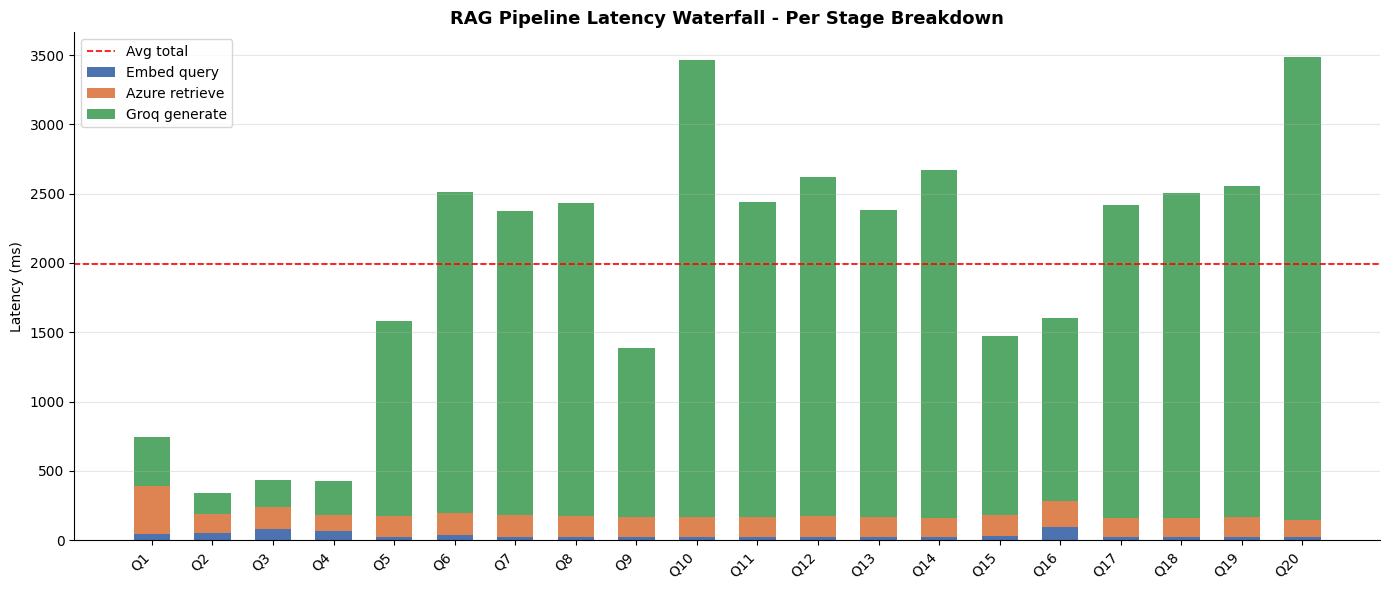

Saved waterfall_breakdown.png


In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(TEST_QUESTIONS))
w = 0.6

ax.bar(x, embed_times,    w, label="Embed query",     color="#4C72B0")
ax.bar(x, retrieve_times, w, bottom=embed_times,
       label="Azure retrieve", color="#DD8452")
ax.bar(x, generate_times, w,
       bottom=[e + r for e, r in zip(embed_times, retrieve_times)],
       label="Groq generate", color="#55A868")

ax.axhline(
    np.mean([e + r + g for e, r, g in zip(embed_times, retrieve_times, generate_times)]),
    color="red", linestyle="--", linewidth=1.2, label="Avg total",
)

ax.set_xticks(x)
ax.set_xticklabels([f"Q{i+1}" for i in range(len(TEST_QUESTIONS))], rotation=45, ha="right")
ax.set_ylabel("Latency (ms)")
ax.set_title("RAG Pipeline Latency Waterfall - Per Stage Breakdown", fontweight="bold", fontsize=13)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("waterfall_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved waterfall_breakdown.png")

#Extension Tasks

##Extension A - Streaming Responses with GROQ

Stream tokens back in real time using the Anthropic client directly. Measure time-to-first-token (perceived responsiveness) vs total latency.

In [40]:
import time
from groq import Groq

# Initialize your existing Groq client
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
direct_client = Groq(api_key=GROQ_API_KEY)

# Set how many documents to retrieve
TOP_K = 5

def rag_stream_groq(query: str, top_k: int = TOP_K):
    """
    Retrieve context using Azure hybrid search and stream Groq response token-by-token.
    """
    # Stage 1: Retrieve
    raw = azure_hybrid_search(query, top_k=top_k)
    context = "\n\n".join([f"[{r['title']}]\n{r['content']}" for r in raw])
    sources = [r["title"] for r in raw]

    print(f"Query: {query}")
    print(f"Sources: {sources}")
    print("\nAnswer (streaming): ", end="", flush=True)

    # Stage 2: Generate streaming response
    t_start = time.perf_counter()
    first_token_ms = None

    stream = direct_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "system",
                "content": "Answer ONLY from the provided context. "
                           "If the answer is not present in the context, say so. Be concise."
            },
            {
                "role": "user",
                "content": f"{context}\n\nQuestion: {query}"
            }
        ],
        max_tokens=512,
        temperature=0,
        stream=True
    )

    for chunk in stream:
        delta = chunk.choices[0].delta.content
        if delta:
            if first_token_ms is None:
                first_token_ms = (time.perf_counter() - t_start) * 1000
            print(delta, end="", flush=True)

    total_ms = (time.perf_counter() - t_start) * 1000
    print(f"\n\nTime to first token: {first_token_ms:.0f}ms | Total: {total_ms:.0f}ms\n")

# ============================================================
# Example usage
# ============================================================

rag_stream_groq("What is the attention mechanism in transformer models?")

Query: What is the attention mechanism in transformer models?
Sources: ['Transformer Architecture', 'Large Language Models', 'Transformer Architecture', 'Natural Language Processing', 'Large Language Models']

Answer (streaming): Self-attention, which computes relationships between all tokens simultaneously.

Time to first token: 124ms | Total: 160ms



##Extension B - Confidence Score Filter

Block answers where no retrieved chunk is relevant enough. We gate on FAISS L2 distance from similarity_search_with_score. Lower L2 distance = more similar. Tune L2_THRESHOLD to calibrate.

In [41]:
# FAISS similarity_search_with_score returns (Document, l2_distance) tuples
# l2_distance is a float32; lower = more similar to the query
# Tune this threshold by inspecting the distribution below
L2_THRESHOLD = 1.0   # reject if best chunk L2 distance > this value

def rag_with_confidence(query: str) -> dict:
    """RAG pipeline that refuses to answer when no chunk is close enough."""
    results_with_scores = faiss_store.similarity_search_with_score(query, k=TOP_K)

    if not results_with_scores:
        return {"answer": "No results found.", "l2_distance": None, "passed": False}

    # scores are numpy float32 -- convert to plain Python float
    best_l2 = float(results_with_scores[0][1])

    if best_l2 > L2_THRESHOLD:
        return {
            "answer": (
                f"I cannot answer this confidently "
                f"(best chunk L2 distance = {best_l2:.3f} > threshold {L2_THRESHOLD}). "
                "Please ask a question related to the topics in the knowledge base."
            ),
            "l2_distance": best_l2,
            "passed": False,
        }

    # Passed threshold -- generate answer
    docs    = [doc for doc, _ in results_with_scores]
    context = "\n\n".join([f"[{d.metadata['title']}]\n{d.page_content}" for d in docs])
    messages = [
        SystemMessage(content="Answer ONLY from the provided context."),
        HumanMessage(content=f"\n{context}\n\n\n{query}"),
    ]
    response = llm.invoke(messages)
    return {"answer": response.content, "l2_distance": best_l2, "passed": True}


# Test with in-corpus and out-of-corpus queries
test_queries = [
    ("What is the attention mechanism in transformers?",   "In-corpus -- should PASS"),
    ("How does CRISPR cut DNA?",                           "In-corpus -- should PASS"),
    ("What is the boiling point of tungsten carbide?",     "Out-of-corpus -- should BLOCK"),
    ("Recommend a good restaurant in Tokyo",               "Out-of-corpus -- should BLOCK"),
]

print(f"Confidence filter (L2 threshold = {L2_THRESHOLD})\n")
for query, label in test_queries:
    result = rag_with_confidence(query)
    status = "PASSED" if result["passed"] else "BLOCKED"
    l2_str = f"{result['l2_distance']:.3f}" if result["l2_distance"] is not None else "N/A"
    print(f"[{status}] {label}")
    print(f"  Q: {query}")
    print(f"  L2={l2_str}  A: {result['answer'][:130]}...\n")


Confidence filter (L2 threshold = 1.0)

[BLOCKED] In-corpus -- should PASS
  Q: What is the attention mechanism in transformers?
  L2=1.020  A: I cannot answer this confidently (best chunk L2 distance = 1.020 > threshold 1.0). Please ask a question related to the topics in ...

[PASSED] In-corpus -- should PASS
  Q: How does CRISPR cut DNA?
  L2=0.647  A: CRISPR-Cas9 cuts DNA by using a guide RNA (gRNA) to direct the Cas9 enzyme to a specific DNA sequence, where it cuts both strands ...

[BLOCKED] Out-of-corpus -- should BLOCK
  Q: What is the boiling point of tungsten carbide?
  L2=1.612  A: I cannot answer this confidently (best chunk L2 distance = 1.612 > threshold 1.0). Please ask a question related to the topics in ...

[BLOCKED] Out-of-corpus -- should BLOCK
  Q: Recommend a good restaurant in Tokyo
  L2=1.646  A: I cannot answer this confidently (best chunk L2 distance = 1.646 > threshold 1.0). Please ask a question related to the topics in ...



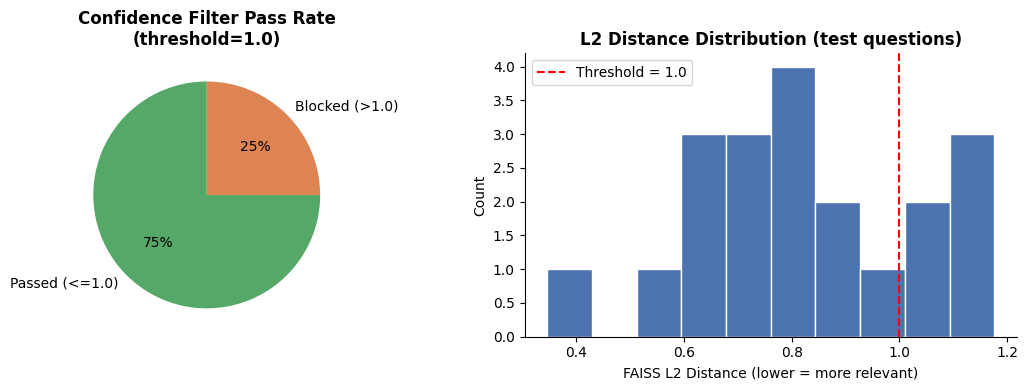

15/20 test questions passed the confidence filter


In [42]:
# Analyse L2 distance distribution on all 20 test questions
l2_scores = []
pass_flags = []
for q in TEST_QUESTIONS:
    res = faiss_store.similarity_search_with_score(q, k=1)
    l2  = float(res[0][1]) if res else float("inf")
    l2_scores.append(l2)
    pass_flags.append(l2 <= L2_THRESHOLD)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Pass/fail pie
passed = sum(pass_flags)
ax1.pie(
    [passed, len(pass_flags) - passed],
    labels=[f"Passed (<={L2_THRESHOLD})", f"Blocked (>{L2_THRESHOLD})"],
    colors=["#55A868", "#DD8452"],
    autopct="%1.0f%%",
    startangle=90,
)
ax1.set_title(f"Confidence Filter Pass Rate\n(threshold={L2_THRESHOLD})", fontweight="bold")

# L2 score histogram
ax2.hist(l2_scores, bins=10, color="#4C72B0", edgecolor="white")
ax2.axvline(L2_THRESHOLD, color="red", linestyle="--", linewidth=1.5,
            label=f"Threshold = {L2_THRESHOLD}")
ax2.set_title("L2 Distance Distribution (test questions)", fontweight="bold")
ax2.set_xlabel("FAISS L2 Distance (lower = more relevant)")
ax2.set_ylabel("Count")
ax2.legend()
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"{passed}/{len(pass_flags)} test questions passed the confidence filter")